In [1]:
import scipy.io
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
from skimage import img_as_float



data = scipy.io.loadmat('facedata.mat')
print("Person index:", data['facedata'].shape[0])
print("Pose index:", data['facedata'].shape[1])

Person index: 40
Pose index: 10


[[48 46 50 ... 50 54 53]
 [47 47 48 ... 37 46 50]
 [46 48 43 ... 33 41 51]
 ...
 [49 49 50 ... 45 46 47]
 [48 48 49 ... 45 46 46]
 [51 48 50 ... 45 45 46]]
(56, 46)


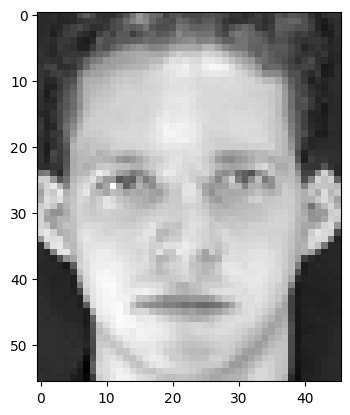

In [2]:
print(data['facedata'][0][0])
print(data['facedata'][0][0].shape)
plt.imshow(data['facedata'][0][0], cmap='gray')
plt.show()

In [3]:
xf = {}
xf[0,0] = img_as_float(data['facedata'][0][0])
print(xf[0,0])

[[0.18823529 0.18039216 0.19607843 ... 0.19607843 0.21176471 0.20784314]
 [0.18431373 0.18431373 0.18823529 ... 0.14509804 0.18039216 0.19607843]
 [0.18039216 0.18823529 0.16862745 ... 0.12941176 0.16078431 0.2       ]
 ...
 [0.19215686 0.19215686 0.19607843 ... 0.17647059 0.18039216 0.18431373]
 [0.18823529 0.18823529 0.19215686 ... 0.17647059 0.18039216 0.18039216]
 [0.2        0.18823529 0.19607843 ... 0.17647059 0.17647059 0.18039216]]


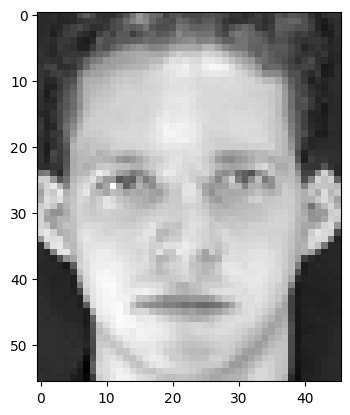

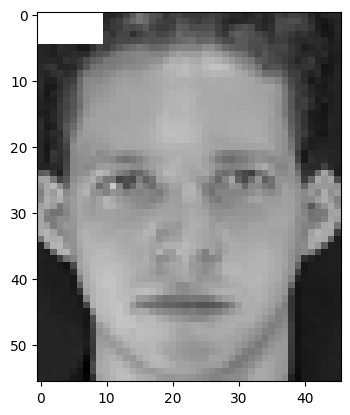

In [4]:
plt.imshow(xf[0,0], cmap='gray')
plt.show()
x_temp = xf[0,0].copy()
x_temp[0:5,0:10] = 1
plt.imshow(x_temp, cmap='gray')
plt.show()

### Part 1

In [5]:
#Euclidean_dis

xf = {}
xf[0,0] = img_as_float(data['facedata'][0][0])
xf[0,1] = img_as_float(data['facedata'][0][1])
xf[1,0] = img_as_float(data['facedata'][1][0])

def euclidean_distance(x1, x2):
    return np.sqrt(np.sum((x1 - x2) ** 2))

print(euclidean_distance(xf[0,0], xf[0,1]))
print(euclidean_distance(xf[0,0], xf[1,0]))

10.037616294165492
8.173295099737281


In [6]:
print("Person index:", data['facedata'].shape[0])
print("Pose index:", data['facedata'].shape[1])

Person index: 40
Pose index: 10


In [7]:
#split data into training and test sets
T = {} # training set
D = {} # test set
for i in range(data['facedata'].shape[0]):
    for j in range(data['facedata'].shape[1]):
        if j < 3:
            T[i,j] = img_as_float(data['facedata'][i][j])
        else:
            D[i,j] = img_as_float(data['facedata'][i][j])

print("Training set size:", len(T))
print("Test set size:", len(D))

Training set size: 120
Test set size: 280


In [8]:
# Create a similarity matrix A where A[i,j] is the Euclidean distance between xf[i] and xf[j]
def compute_similarity_matrix(T,D):
    A = np.zeros((3 * 40, 7 * 40))
    for i in range(40):
        for k in range(3):
            for j in range(40):
                for l in range(7):
                    A[k * 40 + i, l * 40 + j] = euclidean_distance(T[i,k], D[j,3+l])
    return A
A = compute_similarity_matrix(T,D)
print(A.shape)

(120, 280)


In [9]:
A[0,0]

np.float64(10.3696063137365)

In [10]:
# Is similar face reture ture positive and false alarm

def is_similar_face(A, threshold):
    sameface = {}
    true_positives_rate = 0
    true_negatives_rate = 0
    false_negatives_rate = 0
    false_positives_rate = 0
    for l in range(7):
        for i in range(40):
            for j in range(40):
                t = 0
                f = 0
                for k in range(3):
                    if A[k * 40 + j, l * 40 + i] < threshold:
                        if j == i:
                            sameface[l * 40 + i,k] = 1
                            t = 1
                        else:
                            sameface[l * 40 + i,k] = 0
                            t = 2
                    else:
                        if j == i:
                            sameface[l * 40 + i,k] = 0
                            f = 1
                        else:
                            sameface[l * 40 + i,k] = 1
                if t == 1:
                    true_positives_rate += 1
                elif t == 2:
                    false_positives_rate += 1
                elif f == 1:
                    false_negatives_rate += 1
                else:
                    true_negatives_rate += 1
                    
                        
    return true_positives_rate,true_negatives_rate, false_negatives_rate, false_positives_rate
true_positives_rate, true_negatives_rate, false_negatives_rate, false_positives_rate = is_similar_face(A, 10)
print("True positives rate:", true_positives_rate)
print("True negatives rate:", true_negatives_rate)
print("False negatives rate:", false_negatives_rate)
print("False positives rate:", false_positives_rate)


True positives rate: 279
True negatives rate: 5936
False negatives rate: 1
False positives rate: 4984


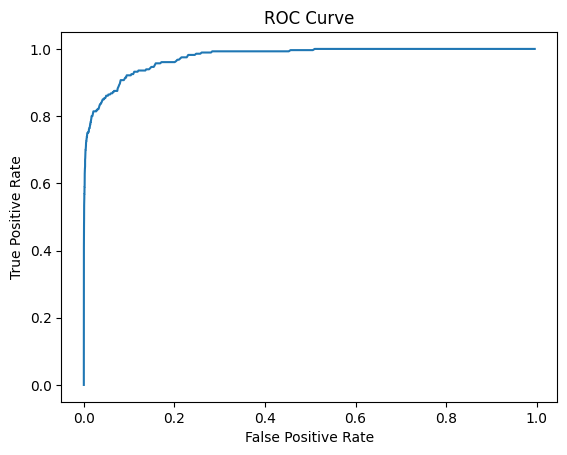

In [11]:
# Plot the ROC curve
num_thresholds = 1000
thresholds = np.linspace(0, 15, num_thresholds)
tpr = []
fpr = []
for threshold in thresholds:
    true_positives_rate, true_negatives_rate, false_negatives_rate, false_positives_rate = is_similar_face(A, threshold)
    tpr.append(true_positives_rate / (true_positives_rate + false_negatives_rate))
    fpr.append(false_positives_rate / (false_positives_rate + true_negatives_rate))
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()

#### Part 5

In [12]:
# PCA
# Compute the mean vector from the training set
D = 56 * 46
mean_vector = np.zeros((1, D))
for i in range(40):
    for k in range(3):
        mean_vector += T[i,k].flatten()
mean_vector /= (40 * 3)
print(mean_vector.shape)



(1, 2576)


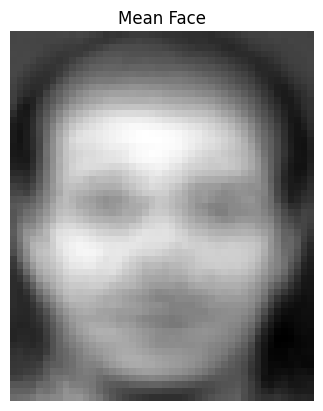

In [13]:
# Plot the mean face
mean_face = mean_vector.reshape(56, 46)
plt.imshow(mean_face, cmap='gray')
plt.title('Mean Face')
plt.axis('off')
plt.show()

In [14]:
# Compute eigenvectors and eigenvalues of the covariance matrix
def compute_covariance_matrix(T, mean_vector):
    C = np.zeros((D, D))
    for i in range(40):
        for k in range(3):
            x = T[i,k].flatten() - mean_vector.flatten()
            C += np.outer(x, x)
    C /= (40 * 3)
    return C
C = compute_covariance_matrix(T, mean_vector)
eigenvalues, eigenvectors = np.linalg.eig(C)
print("Eigenvalues shape:", eigenvalues.shape)
print("Eigenvectors shape:", eigenvectors.shape)

Eigenvalues shape: (2576,)
Eigenvectors shape: (2576, 2576)


In [15]:
# Find Rank of the covariance matrix
rank = np.linalg.matrix_rank(C)
print("Rank of the covariance matrix:", rank)

Rank of the covariance matrix: 119
